# Trabajo práctico 1: Optimización

> Notebook canónico y autocontenido del proyecto.

**Equipo:** Alejandro Quesada, Manfred Azofeifa, Jose Adrián Herrera

**Estado:** trabajo en progreso; análisis gráfico inicial implementado.


## Objetivo y protocolo

- TODO: Resumir el objetivo del experimento.
- TODO: Definir criterios de convergencia y métricas.
- TODO: Registrar decisiones que deban mantenerse entre algoritmos.


## Configuración y reproducibilidad

Esta sección debe concentrar imports, semilla, dispositivo, dominio, número de corridas, puntos iniciales compartidos y demás parámetros globales.


In [52]:
# TODO: Agregar imports y definir aquí toda la configuración compartida.
# TODO: Crear una sola vez los puntos iniciales reutilizados por los algoritmos.
import math
import random
import warnings

import torch
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
from IPython.display import display
import utils

# Constantes a utilizar
DOMAIN_MIN = -10.0
DOMAIN_MAX = 10.0
GRID_POINTS = 401
# Permite ejecutar el notebook desde la raíz del repositorio o desde notebooks/.

## Convención de documentación interna

Documentar cada función con bloques compatibles con Doxygen. Ejemplo genérico:

```python
def metodo(entrada):
    """!
    @brief Descripción breve.
    @param entrada Descripción del parámetro.
    @return Descripción del resultado.
    """
```


### Función auxiliar para graficación de funciones en 2D


In [53]:
def plot_function_2d_3d(x_grid, y_grid, values, title, z_label):
    """!
    @brief Grafica curvas de nivel y una superficie 3D para una función muestreada.
    @param x_grid Malla con las coordenadas x.
    @param y_grid Malla con las coordenadas y.
    @param values Valores de la función sobre la malla.
    @param title Título descriptivo de la figura.
    @param z_label Etiqueta del valor de la función.
    """
    x_values = x_grid.numpy()
    y_values = y_grid.numpy()
    z_values = values.numpy()

    fig = plt.figure(figsize=(14, 5), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    contour_axis = fig.add_subplot(1, 2, 1)
    contours = contour_axis.contourf(
        x_values, y_values, z_values, levels=50, cmap="viridis"
    )
    contour_axis.set(
        xlabel="x", ylabel="y", title="Curvas de nivel",
        xlim=(DOMAIN_MIN, DOMAIN_MAX), ylim=(DOMAIN_MIN, DOMAIN_MAX),
    )
    contour_axis.set_aspect("equal", adjustable="box")
    contour_colorbar = fig.colorbar(contours, ax=contour_axis)
    contour_colorbar.set_label(z_label)

    surface_axis = fig.add_subplot(1, 2, 2, projection="3d")
    surface = surface_axis.plot_surface(
        x_values,
        y_values,
        z_values,
        cmap="viridis",
        rstride=2,
        cstride=2,
        linewidth=0,
        antialiased=True,
    )
    surface_axis.set(
        xlabel="x", ylabel="y", zlabel=z_label, title="Superficie 3D",
        xlim=(DOMAIN_MIN, DOMAIN_MAX), ylim=(DOMAIN_MIN, DOMAIN_MAX),
    )
    surface_axis.view_init(elev=28, azim=-55)
    surface_axis.set_box_aspect((1, 1, 0.65))
    surface_colorbar = fig.colorbar(surface, ax=surface_axis, shrink=0.72, pad=0.10)
    surface_colorbar.set_label(z_label)

    plt.show()


## Análisis de las funciones

Las tres funciones se evalúan sobre una malla compartida en $[-10, 10]^2$ y se muestran mediante curvas de nivel y superficies 3D.

### 1) $f_0(x, y)$  - Función Cuadrática
$$
f_0(x, y) = x^2 + y^2
$$


In [54]:
def f0(x: torch.Tensor):
    """!
    @brief Evalúa la función cuadrática f0 sobre tensores de PyTorch.
    @param x Coordenadas x1 y x2.
    @return Valores de f0(x, y).
    """    
    return x[0] ** 2 + x[1] ** 2



x = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)
y = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)

X, Y = torch.meshgrid(x, y, indexing='ij')
Z0 = f0(torch.stack((X, Y)))
Z0.shape

torch.Size([401, 401])

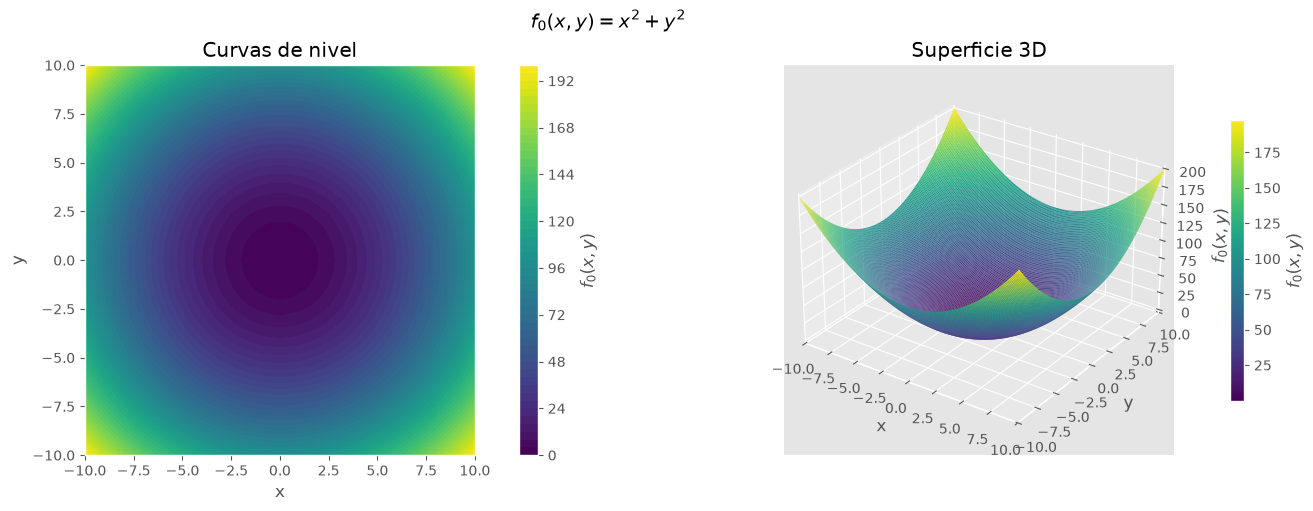

In [55]:
plot_function_2d_3d(X, Y, Z0,
    title=r"$f_0(x, y) = x^2 + y^2$",
    z_label=r"$f_0(x, y)$",
)

### $f_1(x, y)$ - función de Ackley

$$
f_1(x,y) = -20\exp\left[-0.2\sqrt{0.5(x^2+y^2)}\right] - \exp\left[0.5(\cos(2\pi x)+\cos(2\pi y))\right] + e + 20
$$


In [56]:
def f1(x: torch.Tensor):
    """!
    @brief Evalúa la función de Ackley f1 sobre tensores de PyTorch.
    @param x puntos del tensor en ambas dimensiones
    @return Valores de f1(x, y).
    """
    exp1 = -0.2 * torch.sqrt(0.5 * f0(x))
    mitad1 = -20 * torch.exp(exp1)

    exp2 = 0.5 * (torch.cos(2.0 * torch.pi * x[0]) + torch.cos(2.0 * torch.pi * x[1]))
    mitad2 = -torch.exp(exp2)
    return mitad1 + mitad2 + torch.e + 20.0

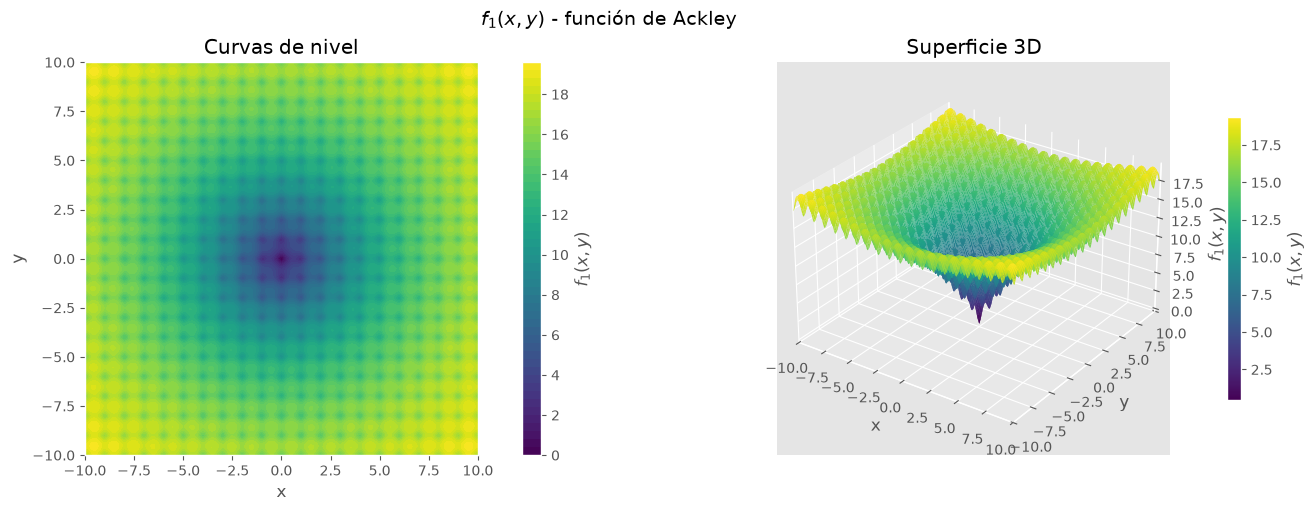

In [57]:
Z1 = f1(torch.stack((X, Y)))
plot_function_2d_3d(X, Y, Z1,
    title=r"$f_1(x, y)$ - función de Ackley",
    z_label=r"$f_1(x, y)$",
)

### $f_2(x, y)$ - función de Himmelblau

$$f_2(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$$


In [58]:
def f2(x: torch.Tensor):
    """!
    @brief Evalúa la función de Himmelblau f2 sobre tensores de PyTorch.
    @param x Coordenadas de la función en un torch.Tensor
    @return Valores de f2(x, y).
    """
    return (x[0] ** 2 + x[1] - 11.0) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2

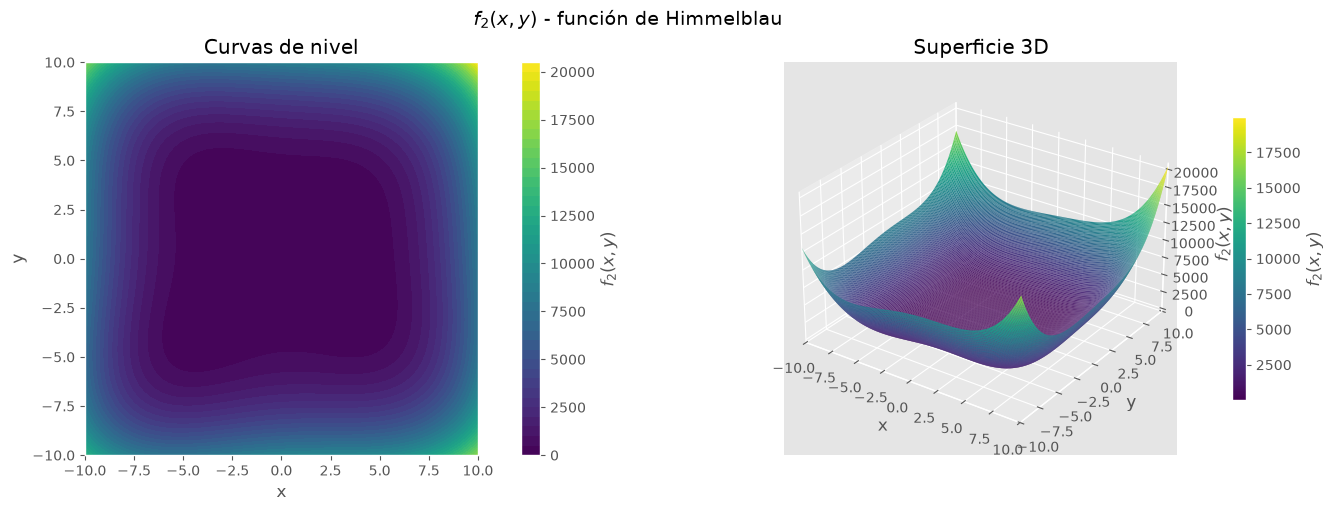

In [59]:
Z2 = f2(torch.stack((X, Y)))
plot_function_2d_3d(X, Y, Z2,
    title=r"$f_2(x, y)$ - función de Himmelblau",
    z_label=r"$f_2(x, y)$",
)

---
### ¿Son convexas o no convexas?

- $f_0$ es convexa.
- $f_1$ y $f_2$ son no convexas.

---
### Encontrando mínimos y puntos silla con PyTorch

Primero usamos la malla que ya construimos. `torch.min(Z)` devuelve el menor **valor muestreado**, mientras que `torch.argmin(Z)` permite recuperar sus coordenadas. Como la malla contiene una cantidad finita de puntos, este resultado es una aproximación cuya precisión depende de `GRID_POINTS`.

Después usamos Autograd para buscar puntos donde el gradiente sea cercano a cero. Esos puntos se clasifican como mínimos locales o puntos silla con una prueba sencilla sobre la Hessiana $2\times2$.

In [60]:
# Valores mínimos aproximados observados en la malla
min0 = torch.min(Z0)
min1 = torch.min(Z1)
min2 = torch.min(Z2)


def coordenadas_minimo_malla(x_grid, y_grid, values):
    """!
    @brief Obtiene las coordenadas del menor valor guardado en una malla.
    @param x_grid Malla con las coordenadas x.
    @param y_grid Malla con las coordenadas y.
    @param values Valores de la función sobre la malla.
    @return Tensor con las coordenadas aproximadas del mínimo.
    """
    flat_index = torch.argmin(values)
    row = flat_index // values.shape[1]
    column = flat_index % values.shape[1]
    return torch.stack((x_grid[row, column], y_grid[row, column]))


puntos_minimos_malla = {
    "f0": coordenadas_minimo_malla(X, Y, Z0),
    "f1": coordenadas_minimo_malla(X, Y, Z1),
    "f2": coordenadas_minimo_malla(X, Y, Z2),
}

resumen_malla = pd.DataFrame(
    [
        {
            "función": "f0",
            "x": puntos_minimos_malla["f0"][0].item(),
            "y": puntos_minimos_malla["f0"][1].item(),
            "valor mínimo en la malla": min0.item(),
        },
        {
            "función": "f1",
            "x": puntos_minimos_malla["f1"][0].item(),
            "y": puntos_minimos_malla["f1"][1].item(),
            "valor mínimo en la malla": min1.item(),
        },
        {
            "función": "f2",
            "x": puntos_minimos_malla["f2"][0].item(),
            "y": puntos_minimos_malla["f2"][1].item(),
            "valor mínimo en la malla": min2.item(),
        },
    ]
)
resumen_malla["valor mínimo en la malla"] = resumen_malla[
    "valor mínimo en la malla"
].map(lambda value: f"{value:.3e}")
display(resumen_malla.round({"x": 6, "y": 6}))

,función,x,y,valor mínimo en la malla
0,f0,-0.0,-0.0,4.441e-14
1,f1,-0.0,-0.0,0.000e+00
2,f2,3.0,2.0,2.274e-13


#### 1. Gradiente y Hessiana con Autograd

Un punto crítico suave cumple $\nabla f(x,y)\approx(0,0)$. Para calcularlo, el tensor `punto` usa `requires_grad=True`. Luego `torch.autograd.grad` obtiene primero las dos componentes del gradiente y después las dos filas de la Hessiana.

In [61]:
# calculo de puntos silla usando pyTorch
def gradiente_y_hessiana(funcion, punto):
    """!
    @brief Calcula valor, gradiente y Hessiana de una función en un punto.
    @param funcion Función de dos variables implementada con PyTorch.
    @param punto Tensor de dos componentes con requires_grad=True.
    @return Tupla con valor, gradiente y matriz Hessiana.
    """
    valor = funcion(punto)
    gradiente = torch.autograd.grad(
        valor, punto, create_graph=True
    )[0]

    filas_hessiana = []
    for componente in gradiente:
        fila = torch.autograd.grad(
            componente, punto, retain_graph=True
        )[0]
        filas_hessiana.append(fila)

    hessiana = torch.stack(filas_hessiana)
    return valor, gradiente, hessiana

#### 2. Refinamiento con el método de Newton

Las curvas de nivel nos dan puntos iniciales aproximados. Desde cada uno aplicamos

$$H(p)\,\text{paso}=\nabla f(p), \qquad p_{nuevo}=p-\text{paso}.$$

`torch.linalg.solve` resuelve el pequeño sistema lineal sin calcular explícitamente $H^{-1}$. Newton puede converger a un mínimo, un máximo o un punto silla; la clasificación se realiza en el paso siguiente.

> Newton depende del punto inicial y puede fallar si la Hessiana no es invertible. En ese caso se debe probar otro inicio tomado de la gráfica.

In [62]:
def encontrar_punto_estacionario(
    funcion,
    inicio,
    max_iteraciones=20,
    tolerancia=1e-8,
):
    """!
    @brief Refina un punto inicial hasta que su gradiente sea cercano a cero.
    @param funcion Función de dos variables implementada con PyTorch.
    @param inicio Tupla con las coordenadas iniciales.
    @param max_iteraciones Máximo de pasos de Newton.
    @param tolerancia Norma máxima del gradiente para detener el método.
    @return Tensor con el punto estacionario aproximado.
    """
    punto = torch.tensor(
        inicio,
        dtype=torch.float64,
        requires_grad=True,
    )

    for _ in range(max_iteraciones):
        _, gradiente, hessiana = gradiente_y_hessiana(
            funcion, punto
        )

        if torch.linalg.vector_norm(gradiente) < tolerancia:
            break

        paso = torch.linalg.solve(hessiana, gradiente)
        # La actualización no debe formar parte del grafo de Autograd.
        with torch.no_grad():
            punto -= paso

    return punto.detach()

#### 3. Clasificación con la Hessiana

Para una Hessiana de dos variables calculamos $D=\det(H)$:

- $D<0$: existen direcciones con curvaturas de signos opuestos, por lo que es un **punto silla**;
- $D>0$ y $f_{xx}>0$: hay curvatura positiva en ambas direcciones, por lo que es un **mínimo local**;
- $D>0$ y $f_{xx}<0$: es un máximo local;
- $D\approx0$: esta prueba no permite concluir.

También guardamos $\lVert\nabla f\rVert$ para comprobar que Newton realmente llegó cerca de un punto estacionario.

In [63]:
def clasificar_punto(funcion, punto, tolerancia=1e-6):
    """!
    @brief Clasifica un punto mediante el gradiente y la Hessiana 2x2.
    @param funcion Función de dos variables implementada con PyTorch.
    @param punto Tensor con las coordenadas del candidato.
    @param tolerancia Tolerancia usada en las comparaciones numéricas.
    @return Diccionario con coordenadas, valor y comprobaciones.
    """
    punto_autograd = punto.clone().detach().requires_grad_(True)
    valor, gradiente, hessiana = gradiente_y_hessiana(
        funcion, punto_autograd
    )

    norma_gradiente = torch.linalg.vector_norm(gradiente).item()
    determinante = torch.det(hessiana).item()
    f_xx = hessiana[0, 0].item()

    if norma_gradiente > tolerancia:
        tipo = "no convergió"
    elif determinante < -tolerancia:
        tipo = "punto silla"
    elif determinante > tolerancia and f_xx > 0:
        tipo = "mínimo local"
    elif determinante > tolerancia and f_xx < 0:
        tipo = "máximo local"
    else:
        tipo = "prueba inconclusa"

    return {
        "punto": punto.detach(),
        "tipo": tipo,
        "x": punto[0].item(),
        "y": punto[1].item(),
        "valor": valor.item(),
        "norma_gradiente": norma_gradiente,
        "det_hessiana": determinante,
    }

In [64]:
def resultados_a_tabla(resultados):
    """!
    @brief Convierte resultados de puntos críticos en una tabla compacta.
    @param resultados Lista de diccionarios creados por clasificar_punto.
    @return DataFrame con los valores necesarios para verificar cada punto.
    """
    columnas = [
        "tipo",
        "x",
        "y",
        "valor",
        "norma_gradiente",
        "det_hessiana",
    ]
    filas = [
        {columna: resultado[columna] for columna in columnas}
        for resultado in resultados
    ]
    tabla = pd.DataFrame(filas)
    tabla["norma_gradiente"] = tabla["norma_gradiente"].map(
        lambda value: f"{value:.2e}"
    )
    return tabla.round(
        {
            "x": 6,
            "y": 6,
            "valor": 6,
            "det_hessiana": 6,
        }
    )

#### 4. Resultados para $f_0$

Como $f_0=x^2+y^2\geq0$, el punto con valor cero es global. Además, su Hessiana es positiva y constante, de manera que no existen puntos silla.

In [65]:
punto_f0 = encontrar_punto_estacionario(f0, inicio=(1.0, 1.0))
resultado_f0 = clasificar_punto(f0, punto_f0)
resultado_f0["tipo"] = "mínimo global"

resultados_f0 = [resultado_f0]
minimos_globales_f0 = [resultado_f0["punto"]]
minimos_locales_f0 = []
puntos_silla_f0 = []

display(resultados_a_tabla(resultados_f0))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,0.0,0.0,0.0,0.00e+00,4.0


#### 5. Resultados para $f_1$ (Ackley)

El mínimo de la malla está en el origen y vale cero. También sabemos que $f_1\geq0$ porque el término radial no puede ser menor que $-20$ y el término periódico no puede ser menor que $-e$; por tanto, $(0,0)$ es el mínimo global.

En el origen la norma euclídea produce una punta no suave, así que no aplicamos allí la prueba Hessiana. Para practicar el procedimiento mostramos mínimos locales y puntos silla **representativos cerca del origen**. Ackley repite este patrón y tiene muchos más en todo $[-10,10]^2$.

In [66]:
inicios_minimos_f1 = [
    (-1.0, 0.0),
    (1.0, 0.0),
    (0.0, -1.0),
    (0.0, 1.0),
    (-1.0, -1.0),
    (-1.0, 1.0),
    (1.0, -1.0),
    (1.0, 1.0),
]
inicios_silla_f1 = [
    (-0.7, 0.0),
    (0.7, 0.0),
    (0.0, -0.7),
    (0.0, 0.7),
]

resultados_f1 = []
for inicio in inicios_minimos_f1 + inicios_silla_f1:
    punto = encontrar_punto_estacionario(f1, inicio)
    resultados_f1.append(clasificar_punto(f1, punto))

minimos_globales_f1 = [
    torch.tensor((0.0, 0.0), dtype=torch.float64)
]
minimos_locales_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "mínimo local"
]
puntos_silla_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "punto silla"
]

display(resultados_a_tabla(resultados_f1))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo local,-0.952167,0.000000,2.579928,6.74e-09,2613.708044
1,mínimo local,0.952167,0.000000,2.579928,6.74e-09,2613.708044
2,mínimo local,0.000000,-0.952167,2.579928,6.74e-09,2613.708044
3,mínimo local,0.000000,0.952167,2.579928,6.74e-09,2613.708044
4,mínimo local,-0.968478,-0.968478,3.574452,5.13e-10,2623.098354
5,mínimo local,-0.968478,0.968478,3.574452,5.13e-10,2623.098354
6,mínimo local,0.968478,-0.968478,3.574452,5.13e-10,2623.098354
7,mínimo local,0.968478,0.968478,3.574452,5.13e-10,2623.098354
8,punto silla,-0.625781,0.000000,3.252469,8.11e-11,-601.475321
9,punto silla,0.625781,0.000000,3.252469,8.11e-11,-601.475321


#### 5.1. Mínimos locales de Ackley en todo el dominio

Los ocho puntos anteriores permiten estudiar la clasificación cerca del origen, pero no son todos los mínimos locales. El término periódico de Ackley produce un pozo cerca de cada punto entero no nulo de $[-10,10]^2$; el término radial desplaza cada mínimo ligeramente hacia el origen.

Usamos cada punto entero no nulo como inicio de Newton, conservamos únicamente los puntos clasificados como mínimos locales dentro del dominio y eliminamos duplicados. Este es un procedimiento numérico, no una demostración analítica de que la lista sea exhaustiva.

In [67]:
def encontrar_minimos_ackley_en_dominio(limite_inferior, limite_superior):
    """Busca mínimos locales de Ackley a partir de la cuadrícula de enteros."""
    minimos = []
    for x0 in range(math.ceil(limite_inferior), math.floor(limite_superior) + 1):
        for y0 in range(math.ceil(limite_inferior), math.floor(limite_superior) + 1):
            if x0 == 0 and y0 == 0:
                continue  # El origen es el mínimo global no suave.

            punto = encontrar_punto_estacionario(
                f1,
                inicio=(float(x0), float(y0)),
            )
            resultado = clasificar_punto(f1, punto)
            dentro_del_dominio = torch.all(
                (punto >= limite_inferior) & (punto <= limite_superior)
            ).item()
            repetido = any(
                torch.linalg.vector_norm(punto - anterior).item() < 1e-5
                for anterior in minimos
            )

            if resultado["tipo"] == "mínimo local" and dentro_del_dominio and not repetido:
                minimos.append(punto)

    return minimos


minimos_locales_f1_dominio = encontrar_minimos_ackley_en_dominio(
    DOMAIN_MIN,
    DOMAIN_MAX,
)
assert len(minimos_locales_f1_dominio) == 440
print(
    f"Se identificaron {len(minimos_locales_f1_dominio)} mínimos locales "
    "de Ackley dentro del dominio."
)

Se identificaron 440 mínimos locales de Ackley dentro del dominio.


#### 6. Resultados para $f_2$ (Himmelblau)

`torch.argmin` mostró un solo mínimo de la malla porque devuelve un único índice. Usamos como inicios puntos aproximados observados en los otros valles de las curvas de nivel. Los cuatro mínimos encontrados hacen que los dos cuadrados de $f_2$ sean prácticamente cero; como una suma de cuadrados nunca es negativa, los cuatro son mínimos globales.

In [68]:
inicios_minimos_f2 = [
    (3.0, 2.0),
    (-3.0, 3.0),
    (-4.0, -3.0),
    (4.0, -2.0),
]
inicios_silla_f2 = [
    (3.0, 0.0),
    (0.0, 3.0),
    (-3.0, 0.0),
    (0.0, -2.0),
]

resultados_f2 = []
for inicio in inicios_minimos_f2 + inicios_silla_f2:
    punto = encontrar_punto_estacionario(f2, inicio)
    resultado = clasificar_punto(f2, punto)
    if resultado["tipo"] == "mínimo local" and abs(resultado["valor"]) < 1e-6:
        resultado["tipo"] = "mínimo global"
    resultados_f2.append(resultado)

minimos_globales_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "mínimo global"
]
minimos_locales_f2 = []
puntos_silla_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "punto silla"
]

display(resultados_a_tabla(resultados_f2))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,3.000000,2.000000,0.000000,0.00e+00,2116.000000
1,mínimo global,-2.805118,3.131313,0.000000,1.13e-14,5222.896681
2,mínimo global,-3.779310,-3.283186,0.000000,6.00e-11,9460.563454
3,mínimo global,3.584428,-1.848127,0.000000,1.88e-11,3024.539865
4,punto silla,3.385154,0.073852,13.311926,3.14e-10,-1378.856668
5,punto silla,0.086678,2.884255,67.719150,5.85e-09,-2394.091252
6,punto silla,-3.073026,-0.081353,104.015163,3.03e-10,-2872.165968
7,punto silla,-0.127961,-1.953715,178.337239,2.34e-10,-1026.580624


#### 7. Verificación numérica

Las siguientes comprobaciones confirman que los puntos suaves tienen gradiente cercano a cero, que el signo del determinante concuerda con su clasificación y que los mínimos globales encontrados tienen valor cercano a cero.

In [69]:
resultados_suaves = resultados_f0 + resultados_f1 + resultados_f2

assert len(minimos_locales_f1) == 8
assert len(minimos_locales_f1_dominio) == 440
assert len(puntos_silla_f1) == 4
assert len(puntos_silla_f2) == 4
assert all(
    resultado["norma_gradiente"] < 1e-6
    for resultado in resultados_suaves
)
assert all(
    resultado["det_hessiana"] < 0
    for resultado in resultados_suaves
    if resultado["tipo"] == "punto silla"
)
assert all(
    resultado["det_hessiana"] > 0
    for resultado in resultados_suaves
    if "mínimo" in resultado["tipo"]
)
assert abs(f0(minimos_globales_f0[0]).item()) < 1e-8
assert abs(f1(minimos_globales_f1[0]).item()) < 1e-8
assert len(minimos_globales_f2) == 4
assert all(
    abs(f2(punto).item()) < 1e-8
    for punto in minimos_globales_f2
)

print("Verificación completada: gradientes, Hessianas y valores globales correctos.")

Verificación completada: gradientes, Hessianas y valores globales correctos.


#### 8. Gráficas de los puntos encontrados

La función `plot_critical_points` se encuentra en `utils.py`. Las estrellas doradas son mínimos globales, los círculos celestes mínimos locales y las equis rojas puntos silla. Estas gráficas usan una vista cercana para distinguir los marcadores; las gráficas anteriores conservan el dominio completo $[-10,10]^2$.

El color usa $\log(1+f)$ únicamente para que los valles sean visibles; las coordenadas y los valores de los puntos no se modifican.

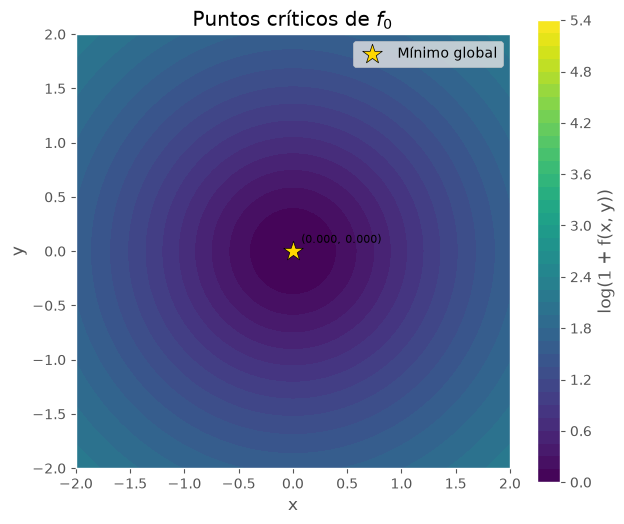

In [70]:
utils.plot_critical_points(
    X,
    Y,
    Z0,
    minimos_globales_f0,
    minimos_locales_f0,
    puntos_silla_f0,
    title=r"Puntos críticos de $f_0$",
    view_limits=(-2.0, 2.0),
)

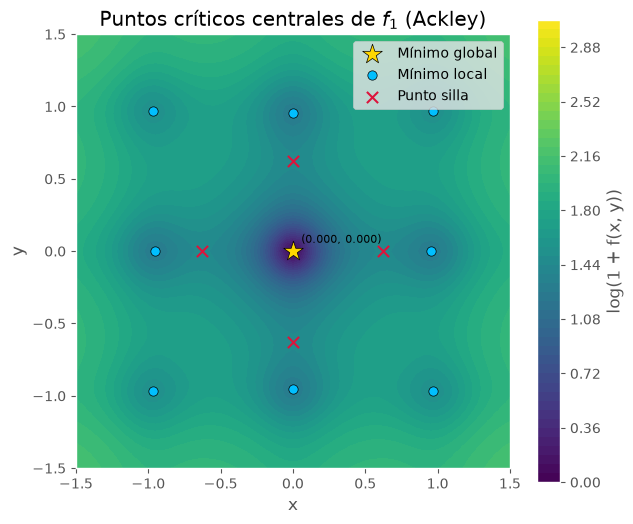

In [71]:
utils.plot_critical_points(
    X,
    Y,
    Z1,
    minimos_globales_f1,
    minimos_locales_f1,
    puntos_silla_f1,
    title=r"Puntos críticos centrales de $f_1$ (Ackley)",
    view_limits=(-1.5, 1.5),
)

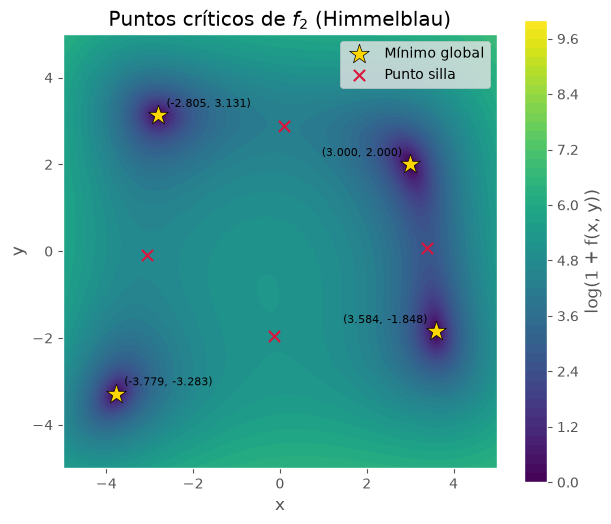

In [72]:
utils.plot_critical_points(
    X,
    Y,
    Z2,
    minimos_globales_f2,
    minimos_locales_f2,
    puntos_silla_f2,
    title=r"Puntos críticos de $f_2$ (Himmelblau)",
    view_limits=(-5.0, 5.0),
)

## Descenso del gradiente

### 1. Cálculo del gradiente con Autograd

Al crear un tensor con `requires_grad=True`, PyTorch registra las operaciones usadas para calcular la función. Después, `torch.autograd.grad(valor, punto)` obtiene el gradiente de **la función que se recibió como parámetro**.

La función de Ackley no es diferenciable exactamente en el origen por el término con la raíz cuadrada. Por eso la comprobación se realiza en el punto $(1, 1)$.

In [73]:
def valor_y_gradiente(funcion, punto):
    """Calcula el valor de una función y su gradiente en un punto."""
    valor = funcion(punto)
    gradiente = torch.autograd.grad(valor, punto)[0]
    return valor, gradiente

In [74]:
def run_gd(alpha, t, func, punto_inicial):
    """Ejecuta t pasos de descenso del gradiente usando Autograd."""
    xt = torch.tensor(
        punto_inicial,
        dtype=torch.float64,
        requires_grad=True,
    )
    f_hist = []
    x_hist = []

    for _ in range(t):
        f_xt, gradiente = valor_y_gradiente(func, xt)
        if not torch.isfinite(f_xt) or not torch.isfinite(gradiente).all():
            raise ValueError(
                "GD divergió: pruebe una tasa de aprendizaje más pequeña."
            )

        f_hist.append(f_xt.detach().clone())
        x_hist.append(xt.detach().clone())

        # x_(t+1) = x_t - alpha * gradiente de la función recibida.
        xt = (xt - alpha * gradiente).detach().requires_grad_(True)

    # Se guarda también el punto obtenido después de la última actualización.
    x_hist.append(xt.detach().clone())
    f_hist.append(func(xt).detach().clone())

    return torch.stack(x_hist), torch.stack(f_hist)

In [75]:
def generar_punto_inicial():
    """Genera un punto uniforme al azar dentro del dominio de trabajo."""
    return (random.uniform(DOMAIN_MIN, DOMAIN_MAX),
        random.uniform(DOMAIN_MIN, DOMAIN_MAX))

### 2. Aplicación a $f_0$

El punto inicial se selecciona uniformemente al azar dentro de $[-10,10]^2$.

In [76]:
p0_inicial = generar_punto_inicial()
X0_hist, f0_hist = run_gd(
    alpha=0.1,
    t=25,
    func=f0,
    punto_inicial=p0_inicial,
)
print(f"Punto inicial de f0: {p0_inicial}")

Punto inicial de f0: (9.387664345379353, -4.359767161575741)


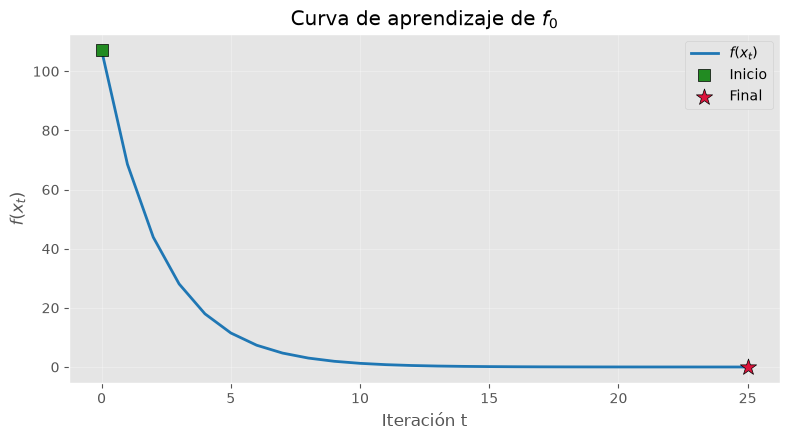

In [77]:
utils.plot_learning_curve(
    f0_hist,
    title=r"Curva de aprendizaje de $f_0$",
);

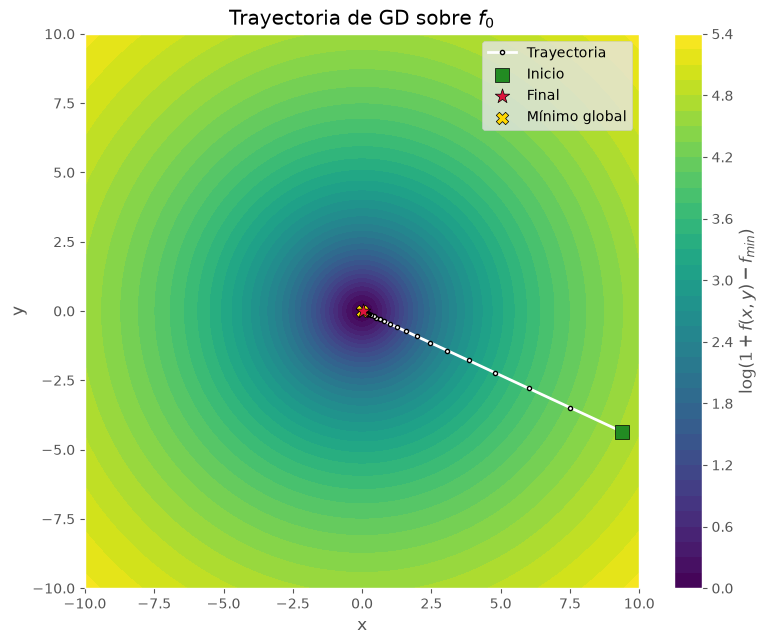

In [78]:
utils.plot_func_hist(
    x,
    y,
    f0,
    X0_hist,
    title=r"Trayectoria de GD sobre $f_0$",
    minima=minimos_globales_f0);

### 3. Aplicación a $f_1$

Ackley tiene 440 mínimos locales suaves en el dominio, además del mínimo global en el origen. Un inicio aleatorio puede conducir a cualquiera de sus cuencas de atracción.

In [79]:
p1_inicial = generar_punto_inicial()
X1_hist, f1_hist = run_gd(
    alpha=0.01,
    t=25,
    func=f1,
    punto_inicial=p1_inicial,
)
print(f"Punto inicial de f1: {p1_inicial}")

Punto inicial de f1: (8.888636345671316, 8.009369199588438)


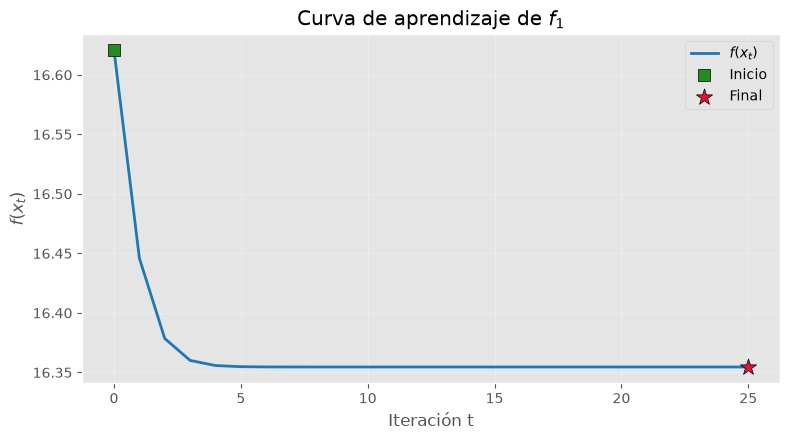

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Curva de aprendizaje de $f_1$'}, xlabel='Iteración t', ylabel='$f(x_t)$'>)

In [80]:
utils.plot_learning_curve(f1_hist, title=r"Curva de aprendizaje de $f_1$")

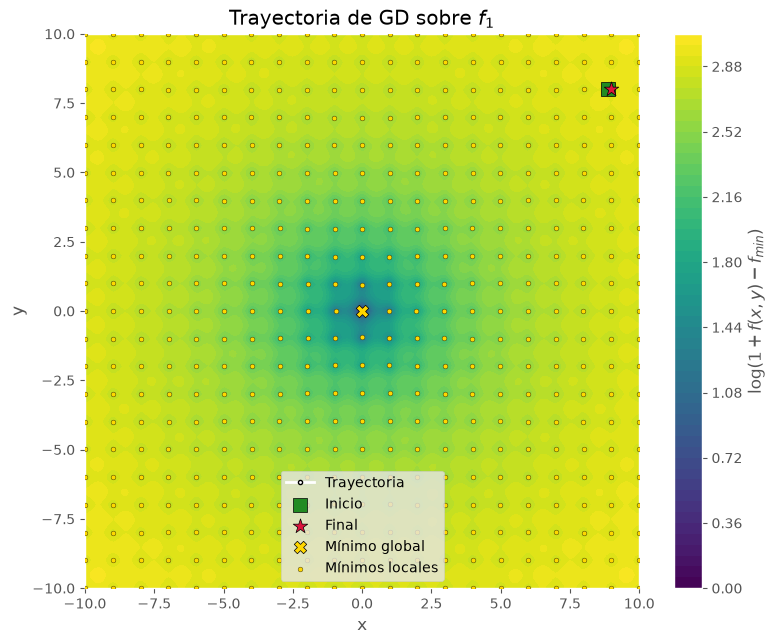

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de GD sobre $f_1$'}, xlabel='x', ylabel='y'>)

In [81]:
utils.plot_func_hist(x, y, f1, X1_hist,
    title=r"Trayectoria de GD sobre $f_1$",
    minima=minimos_globales_f1,
    local_minima=minimos_locales_f1_dominio)

### 4. Aplicación a $f_2$

El inicio sigue siendo aleatorio en $[-10,10]^2$, pero aquí se necesita un paso menor. $f_2$ es una función de grado cuatro, por lo que su gradiente crece aproximadamente como el cubo de las coordenadas lejos de los mínimos.

Por ejemplo, en $(10,10)$ el gradiente es aproximadamente $(4166,4318)$. Con $\alpha=0.01$, un solo paso lleva a $(-31.66,-33.18)$; fuera del dominio el siguiente gradiente es todavía mayor y la sucesión puede desbordarse. Esto no es un problema del inicio aleatorio, sino de usar un paso demasiado grande para las zonas más empinadas.

Usamos $\alpha=0.002$ y más iteraciones. Así se conserva el descenso del gradiente básico y el requisito de iniciar al azar.

In [82]:
p2_inicial = generar_punto_inicial()
X2_hist, f2_hist = run_gd(alpha=0.002, t=25,func=f2, punto_inicial=p2_inicial)
print(f"Punto inicial de f2: {p2_inicial}")

Punto inicial de f2: (-6.436248081534323, -6.159179149203187)


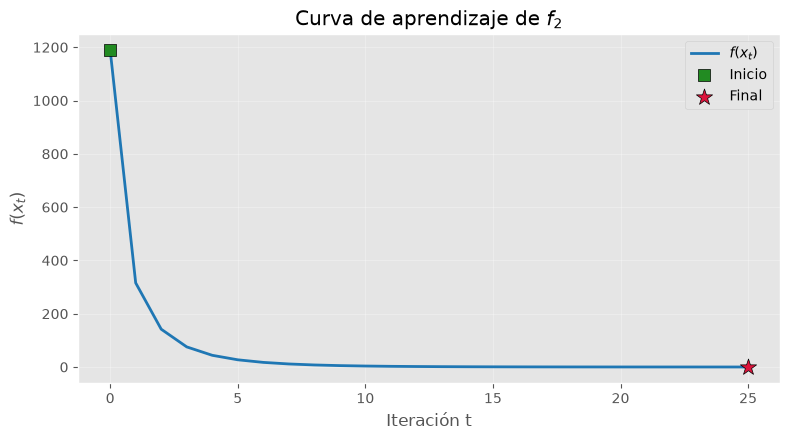

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Curva de aprendizaje de $f_2$'}, xlabel='Iteración t', ylabel='$f(x_t)$'>)

In [83]:
utils.plot_learning_curve(
    f2_hist,
    title=r"Curva de aprendizaje de $f_2$")

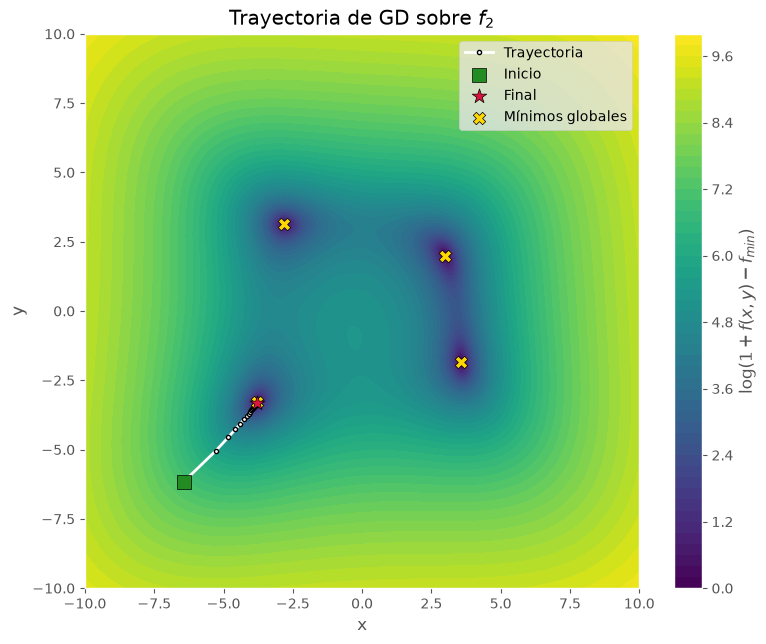

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de GD sobre $f_2$'}, xlabel='x', ylabel='y'>)

In [84]:
utils.plot_func_hist(x, y, f2, X2_hist,
    title=r"Trayectoria de GD sobre $f_2$",
    minima=minimos_globales_f2)

---
## RMSProp

RMSProp conserva un promedio móvil, por coordenada, de los gradientes al cuadrado. Así toma del método de momentum la idea de dar más peso a la información reciente, pero la usa para adaptar la escala de cada componente del paso:

$$
\mathbf{s}_t = \gamma \mathbf{s}_{t-1} + (1-\gamma)\mathbf{g}_t^2,
\qquad
\mathbf{x}_{t+1} = \mathbf{x}_t -
\frac{\alpha}{\sqrt{\mathbf{s}_t + \epsilon}}\odot\mathbf{g}_t.
$$

Se usa $\mathbf{s}_0=\mathbf{0}$, $\gamma=0.9$ y $\epsilon=10^{-6}$. Cada experimento ejecuta 25 actualizaciones y reutiliza el punto inicial de descenso del gradiente correspondiente, de modo que la comparación parte de la misma solución. La implementación sigue la formulación de [Dive into Deep Learning: RMSProp](https://d2l.ai/chapter_optimization/rmsprop.html).

In [85]:
def run_rmsprop(alpha, gamma, epsilon, t, func, punto_inicial):
    """!
    @brief Ejecuta t pasos de RMSProp usando gradientes calculados con Autograd.
    @param alpha Tasa de aprendizaje.
    @param gamma Peso del promedio móvil de gradientes al cuadrado.
    @param epsilon Constante positiva que estabiliza la división.
    @param t Cantidad de actualizaciones.
    @param func Función objetivo que recibe un tensor bidimensional.
    @param punto_inicial Coordenadas iniciales dentro del dominio de trabajo.
    @return Historiales apilados de puntos y valores, incluido el estado final.
    """
    xt = torch.tensor(punto_inicial, requires_grad=True)
    promedio_cuadrados = torch.zeros_like(xt)
    f_hist = []
    x_hist = []

    for _ in range(t):
        f_xt, gradiente = valor_y_gradiente(func, xt)
        if not torch.isfinite(f_xt) or not torch.isfinite(gradiente).all():
            raise ValueError("RMSProp divergió: revise la tasa de aprendizaje.")

        f_hist.append(f_xt.detach().clone())
        x_hist.append(xt.detach().clone())

        # Promedio móvil por coordenada propuesto para RMSProp.
        promedio_cuadrados = (
            gamma * promedio_cuadrados
            + (1.0 - gamma) * gradiente.square()
        )
        if not torch.isfinite(promedio_cuadrados).all():
            raise ValueError("RMSProp divergió: el promedio de gradientes no es finito.")

        paso = alpha * gradiente / torch.sqrt(promedio_cuadrados + epsilon)
        xt = (xt - paso).detach().requires_grad_(True)

    # Se guarda también el punto obtenido después de la última actualización.
    x_hist.append(xt.detach().clone())
    f_hist.append(func(xt).detach().clone())

    return torch.stack(x_hist), torch.stack(f_hist)

### Aplicación de RMSProp a $f_0$

Para la función cuadrática se usa $\alpha=0.5$.

f0: 107.135818 -> 0.020914


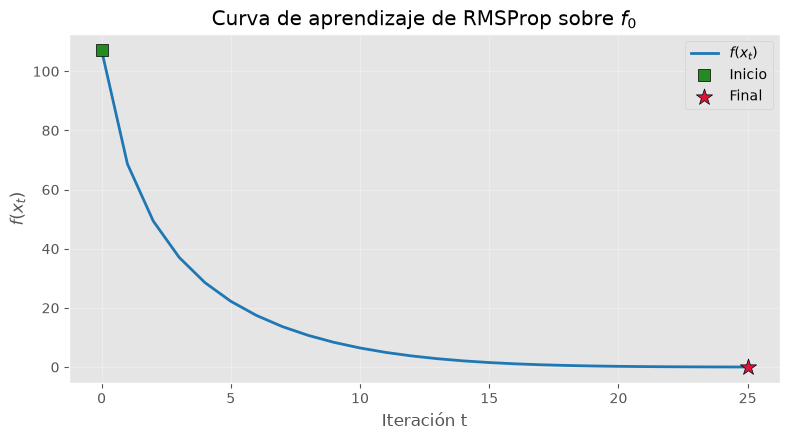

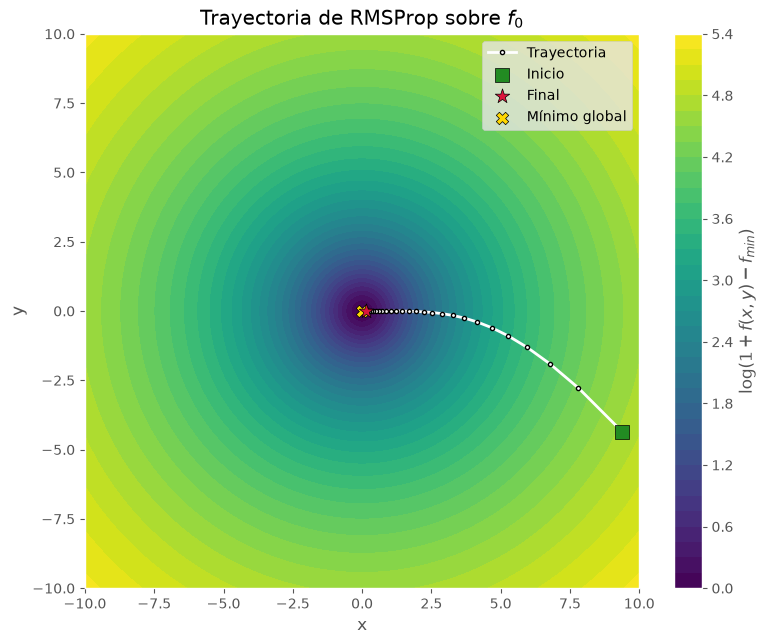

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_0$'}, xlabel='x', ylabel='y'>)

In [86]:
X0_rms_hist, f0_rms_hist = run_rmsprop(
    alpha=0.5,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f0,
    punto_inicial=p0_inicial,
)

print(
    f"f0: {f0_rms_hist[0].item():.6f} -> "
    f"{f0_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f0_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_0$",
)

utils.plot_func_hist(
    x,
    y,
    f0,
    X0_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_0$",
    minima=minimos_globales_f0,
)

### Aplicación de RMSProp a $f_1$

Ackley puede conducir a un mínimo local distinto del origen. Se usa un paso conservador $\alpha=0.05$.

f1: 16.620710 -> 16.389915


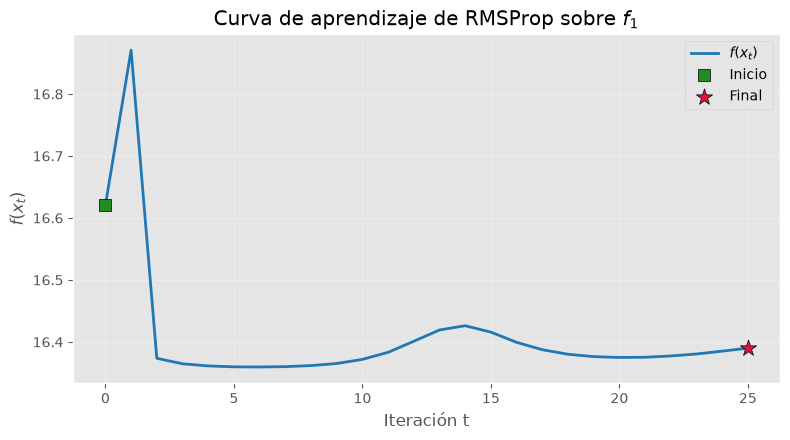

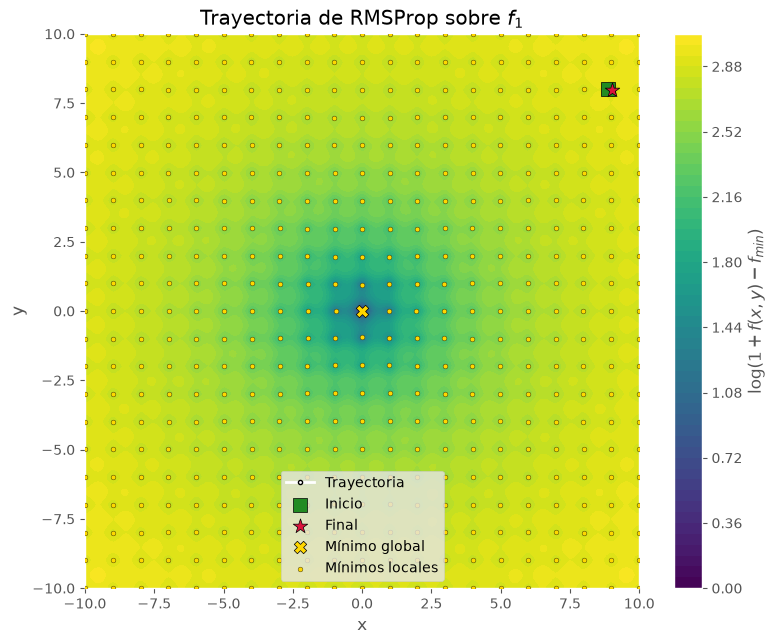

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_1$'}, xlabel='x', ylabel='y'>)

In [87]:
X1_rms_hist, f1_rms_hist = run_rmsprop(
    alpha=0.05,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f1,
    punto_inicial=p1_inicial,
)
print(
    f"f1: {f1_rms_hist[0].item():.6f} -> "
    f"{f1_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f1_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_1$",
)

utils.plot_func_hist(
    x,
    y,
    f1,
    X1_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_1$",
    minima=minimos_globales_f1,
    local_minima=minimos_locales_f1_dominio,
)

### Aplicación de RMSProp a $f_2$

Para Himmelblau se usa $\alpha=0.4$; el escalado por coordenada mantiene controlados los pasos en las regiones empinadas.

f2: 1189.057129 -> 0.000001


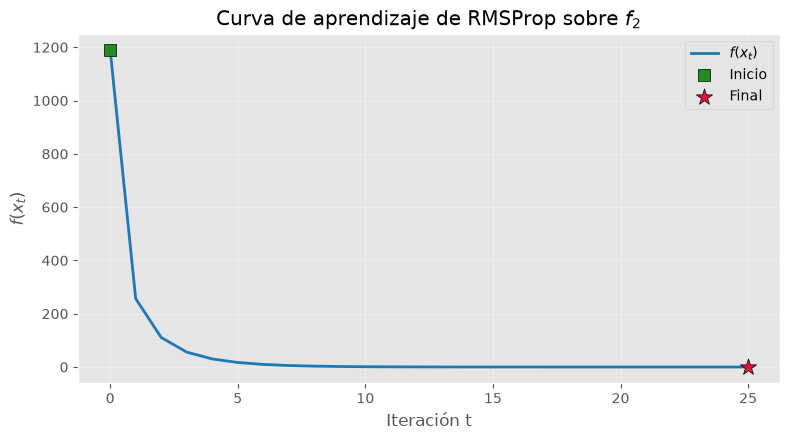

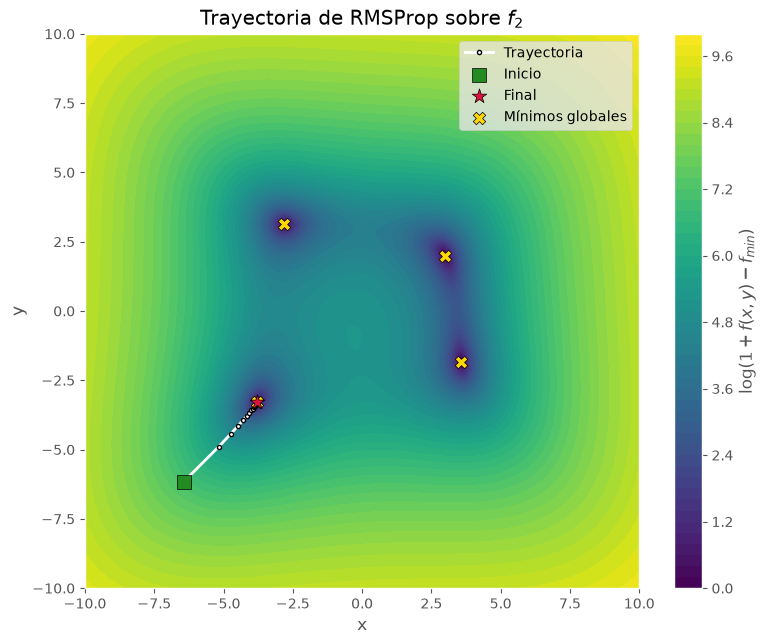

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_2$'}, xlabel='x', ylabel='y'>)

In [88]:
X2_rms_hist, f2_rms_hist = run_rmsprop(
    alpha=0.4,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f2,
    punto_inicial=p2_inicial,
)
print(
    f"f2: {f2_rms_hist[0].item():.6f} -> "
    f"{f2_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f2_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_2$",
)

utils.plot_func_hist(
    x,
    y,
    f2,
    X2_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_2$",
    minima=minimos_globales_f2,
)

---
## Enjambre de Partículas _(Particle Swarm Optimization)_


In [89]:
#TODO: Implementar PSO

---
## Calibración de hiperparámetros con Optuna

En esta sección usamos Optuna para buscar dos hiperparámetros de descenso del gradiente:

- `alpha`: tamaño del paso;
- `iteraciones`: cantidad de actualizaciones realizadas.

Cada ensayo se evalúa desde los **mismos seis puntos seleccionados al azar** en $[-10,10]^2$. Fijarlos durante el estudio permite comparar configuraciones: si cada ensayo usara puntos distintos, una configuración podría parecer mejor solo por haber recibido inicios más fáciles.

In [90]:
generador_optuna = random.Random(42)
TOLERANCIA_GRADIENTE_OPTUNA = 1e-3 #0.001
puntos_validacion_optuna = [
    (
        generador_optuna.uniform(DOMAIN_MIN, DOMAIN_MAX),
        generador_optuna.uniform(DOMAIN_MIN, DOMAIN_MAX),
    )
    for _ in range(6)
]

configuraciones_optuna = {
    "f0": {
        "funcion": f0,
        "alpha_min": 0.01,
        "alpha_max": 0.49,
        "iter_min": 25,
        "iter_max": 80,
        "paso_iter": 5,
    },
    "f1": {
        "funcion": f1,
        "alpha_min": 0.001,
        "alpha_max": 0.5,
        "iter_min": 25,
        "iter_max": 250,
        "paso_iter": 25,
    },
    "f2": {
        "funcion": f2,
        "alpha_min": 0.0002,
        "alpha_max": 0.04,
        "iter_min": 10,
        "iter_max": 560,
        "paso_iter": 50,
    },
}

display(
    pd.DataFrame(
        puntos_validacion_optuna,
        columns=["x inicial", "y inicial"],
    ).round(4)
)
display(
    pd.DataFrame(
        [
            {
                "función": nombre,
                "alpha mínimo": config["alpha_min"],
                "alpha máximo": config["alpha_max"],
                "iteraciones mínimas": config["iter_min"],
                "iteraciones máximas": config["iter_max"],
            }
            for nombre, config in configuraciones_optuna.items()
        ]
    )
)

,x inicial,y inicial
0,2.7885,-9.4998
1,-4.4994,-5.5358
2,4.7294,3.5340
3,7.8436,-8.2612
4,-1.5616,-9.4041
5,-5.6272,0.1071


,función,alpha mínimo,alpha máximo,iteraciones mínimas,iteraciones máximas
0,f0,0.0100,0.49,25,80
1,f1,0.0010,0.50,25,250
2,f2,0.0002,0.04,10,560


### 1. Función objetivo del estudio

Para cada configuración ejecutamos GD desde los seis puntos y minimizamos

$$\text{score}=\frac{1}{6}\sum_{i=1}^{6} f\left(x_{final}^{(i)}\right).$$

Si una configuración diverge o termina con una norma de gradiente mayor que $10^{-3}$, recibe una penalización grande. Este score mide la calidad final, pero **no penaliza el tiempo de ejecución**; por eso Optuna puede preferir una cantidad alta de iteraciones.

In [91]:
def crear_objetivo_optuna(configuracion, puntos_iniciales):
    """Crea la función que Optuna minimiza para una función dada."""
    funcion = configuracion["funcion"]

    def objetivo(trial):
        alpha = trial.suggest_float(
            "alpha",
            configuracion["alpha_min"],
            configuracion["alpha_max"],
            log=True,
        )
        iteraciones = trial.suggest_int(
            "iteraciones",
            configuracion["iter_min"],
            configuracion["iter_max"],
            step=configuracion["paso_iter"],
        )

        valores_finales = []
        for punto_inicial in puntos_iniciales:
            try:
                puntos_historial, historial = run_gd(
                    alpha=alpha,
                    t=iteraciones,
                    func=funcion,
                    punto_inicial=punto_inicial,
                )
                punto_final = (
                    puntos_historial[-1]
                    .detach()
                    .clone()
                    .requires_grad_(True)
                )
                _, gradiente_final = valor_y_gradiente(
                    funcion,
                    punto_final,
                )
                if (
                    torch.linalg.vector_norm(gradiente_final)
                    > TOLERANCIA_GRADIENTE_OPTUNA
                ):
                    return 1e6
                valores_finales.append(historial[-1].item())
            except ValueError:
                return 1e6

        return float(np.mean(valores_finales))

    return objetivo

In [92]:
def plot_estudio_optuna(estudio, nombre_funcion):
    """Muestra el progreso y la relación entre parámetros y score."""
    ensayos = [
        trial
        for trial in estudio.trials
        if trial.value is not None and np.isfinite(trial.value)
    ]
    valores = [trial.value for trial in ensayos]
    usar_escala_log = (
        len(valores) > 0
        and all(valor > 0 for valor in valores)
        and max(valores) / min(valores) > 100
    )

    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            category=optuna.exceptions.ExperimentalWarning,
        )
        axis = optuna.visualization.matplotlib.plot_optimization_history(
            estudio,
            target_name=r"Promedio de $f(x_{final})$",
        )

    axis.set_title(f"Historial de optimización para {nombre_funcion}")
    axis.figure.set_size_inches(8, 4.5)
    if usar_escala_log:
        axis.set_yscale("log")
    plt.show()

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4.5),
        sharey=True,
    )
    mejor_ensayo = estudio.best_trial
    for current_axis, parametro in zip(
        axes,
        ["alpha", "iteraciones"],
    ):
        valores_parametro = [
            trial.params[parametro]
            for trial in ensayos
        ]
        current_axis.scatter(
            valores_parametro,
            valores,
            color="tab:blue",
            alpha=0.75,
            label="Ensayos",
        )
        current_axis.scatter(
            mejor_ensayo.params[parametro],
            mejor_ensayo.value,
            marker="*",
            s=160,
            color="crimson",
            edgecolor="black",
            label="Mejor ensayo",
            zorder=3,
        )
        current_axis.set_xlabel(parametro)
        current_axis.grid(alpha=0.3)
        if parametro == "alpha":
            current_axis.set_xscale("log")
        if usar_escala_log:
            current_axis.set_yscale("log")

    axes[0].set_ylabel(r"Promedio de $f(x_{final})$")
    axes[0].legend()
    figure.suptitle(f"Efecto de los hiperparámetros para {nombre_funcion}")
    figure.tight_layout()
    plt.show()

### 2. Ejecución de los estudios

El muestreador TPE propone nuevas configuraciones usando los resultados de ensayos anteriores. La semilla hace que el experimento sea reproducible.

In [93]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS_OPTUNA = 25
estudios_optuna = {}

for indice, (nombre, configuracion) in enumerate(configuraciones_optuna.items()):
    estudio = optuna.create_study(
        direction="minimize",
        study_name=f"GD_{nombre}",
        sampler=optuna.samplers.TPESampler(seed=42 + indice),
    )
    estudio.optimize(
        crear_objetivo_optuna(
            configuracion,
            puntos_validacion_optuna,
        ),
        n_trials=N_TRIALS_OPTUNA,
        show_progress_bar=False,
    )
    estudios_optuna[nombre] = estudio
    print(f"Estudio de {nombre} completado: {len(estudio.trials)} ensayos.")

Estudio de f0 completado: 25 ensayos.
Estudio de f1 completado: 25 ensayos.
Estudio de f2 completado: 25 ensayos.


### 3. Gráficas del proceso de búsqueda

El historial muestra el score de cada ensayo y el mejor score acumulado. Los gráficos de cortes permiten observar por separado cómo `alpha` y `iteraciones` se relacionan con el resultado.

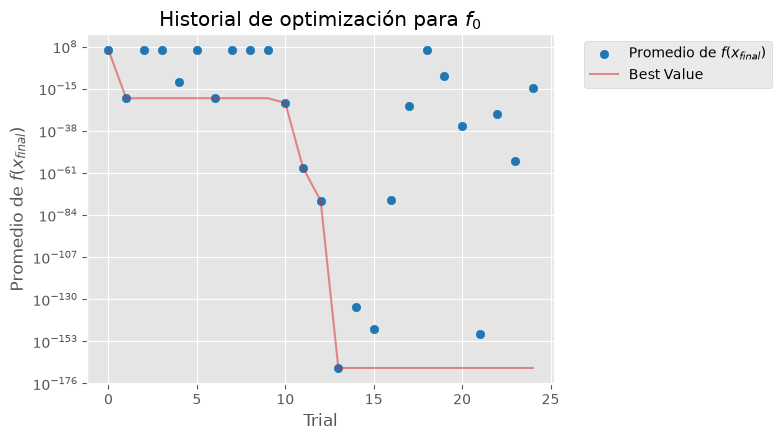

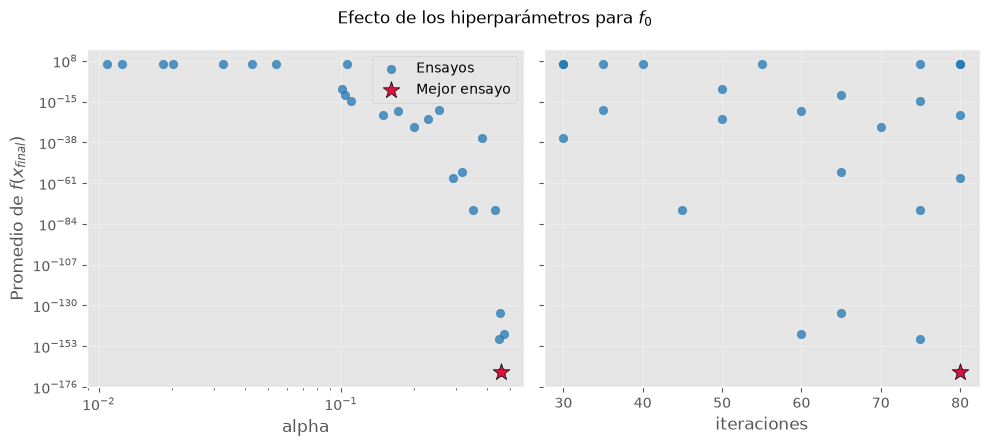

In [94]:
plot_estudio_optuna(estudios_optuna["f0"], r"$f_0$")

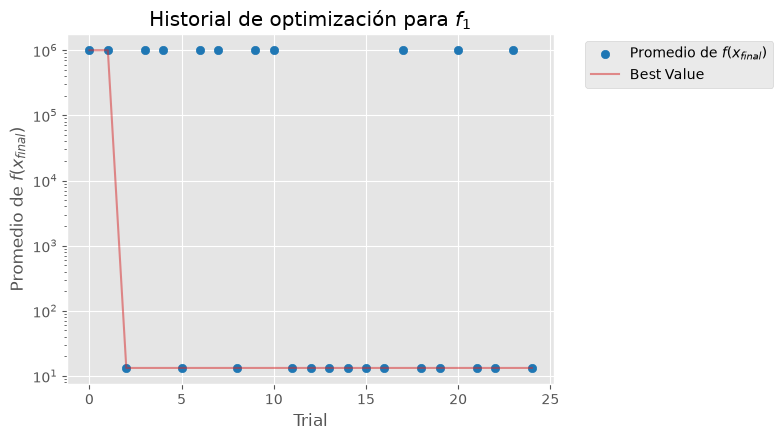

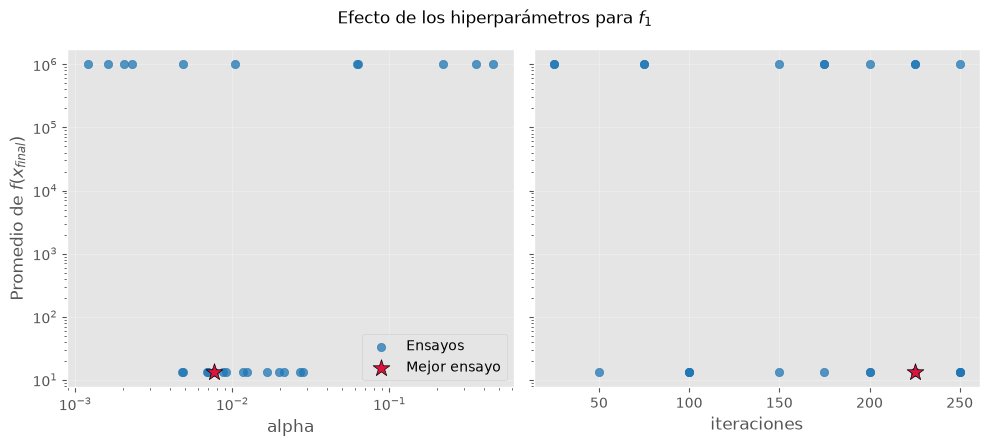

In [95]:
plot_estudio_optuna(estudios_optuna["f1"], r"$f_1$")

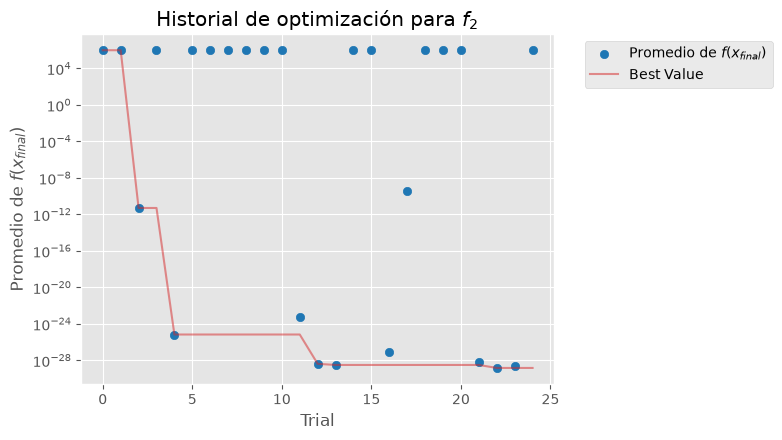

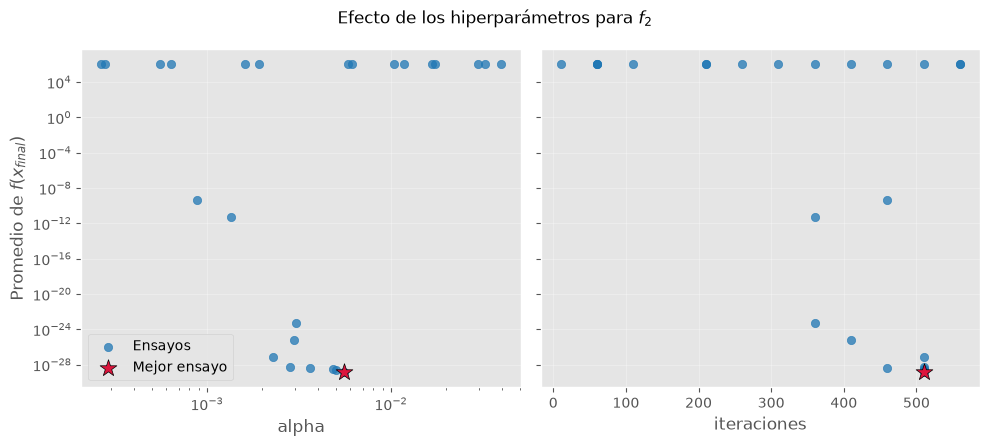

In [96]:
plot_estudio_optuna(estudios_optuna["f2"], r"$f_2$")

### 4. Mejores hiperparámetros encontrados

La última columna es el promedio de los seis valores finales usados por Optuna. En Ackley este promedio puede permanecer lejos de cero porque los inicios aleatorios terminan en distintos mínimos locales.

In [97]:
resumen_optuna = pd.DataFrame(
    [
        {
            "función": nombre,
            "mejor alpha": estudio.best_params["alpha"],
            "mejores iteraciones": estudio.best_params["iteraciones"],
            "promedio f(x_final)": estudio.best_value,
            "número de ensayo": estudio.best_trial.number,
        }
        for nombre, estudio in estudios_optuna.items()
    ]
)

display(
    resumen_optuna.style.format(
        {
            "mejor alpha": "{:.6g}",
            "promedio f(x_final)": "{:.6e}",
        }
    )
)

,función,mejor alpha,mejores iteraciones,promedio f(x_final),número de ensayo
0,f0,0.456334,80,2.809441e-168,13
1,f1,0.00763728,225,1.330575e+01,2
2,f2,0.00552217,510,1.459393e-29,22


## Pruebas unitarias

Mantener aquí al menos dos pruebas documentadas por cada método. Las pruebas forman parte del notebook autocontenido.


In [99]:
def probar_actualizacion_rmsprop():
    """!
    @brief Verifica una actualización de RMSProp contra la ecuación explícita.
    @return None. Falla mediante una aserción si la actualización no coincide.
    """
    alpha = 0.1
    gamma = 0.9
    epsilon = 1e-6
    punto_inicial = (1.0, -2.0)
    punto = torch.tensor(punto_inicial)

    x_hist, f_hist = run_rmsprop(
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        t=1,
        func=f0,
        punto_inicial=punto_inicial,
    )

    gradiente_esperado = 2.0 * punto
    promedio_esperado = (
        (1.0 - gamma) * gradiente_esperado.square()
    )
    punto_esperado = punto - (
        alpha
        * gradiente_esperado
        / torch.sqrt(promedio_esperado + epsilon)
    )

    torch.testing.assert_close(x_hist[1], punto_esperado)
    torch.testing.assert_close(f_hist[1], f0(punto_esperado))


def probar_historiales_rmsprop():
    """!
    @brief Verifica forma, finitud y progreso en las tres funciones objetivo.
    @return None. Falla mediante una aserción si algún historial es inválido.
    """
    casos = (
        ("f0", f0, (4.0, -3.0), 0.5),
        ("f1", f1, (2.5, -1.5), 0.05),
        ("f2", f2, (6.0, 6.0), 0.4),
    )

    for nombre, funcion, punto, alpha in casos:
        x_hist, f_hist = run_rmsprop(
            alpha=alpha,
            gamma=0.9,
            epsilon=1e-6,
            t=25,
            func=funcion,
            punto_inicial=punto,
        )

        assert x_hist.shape == (26, 2), nombre
        assert f_hist.shape == (26,), nombre
        assert torch.isfinite(x_hist).all(), nombre
        assert torch.isfinite(f_hist).all(), nombre
        torch.testing.assert_close(
            x_hist[0],
            torch.tensor(punto),
        )
        assert f_hist[-1] < f_hist[0], nombre


probar_actualizacion_rmsprop()
probar_historiales_rmsprop()
print("Las dos pruebas unitarias de RMSProp finalizaron correctamente.")

# TODO: Agregar las pruebas unitarias de los demás métodos.

Las dos pruebas unitarias de RMSProp finalizaron correctamente.


## Evaluación y resultados

- TODO: Ejecutar el protocolo común y resumir las corridas.
- TODO: Conservar tablas, curvas y trayectorias finales.


In [100]:
# TODO: Evaluación comparativa y resultados finales.


## Comparación, conclusiones y referencias

- TODO: Comparar los métodos a partir de resultados reproducibles.
- TODO: Responder las preguntas conceptuales y citar fuentes externas.
- TODO: Registrar limitaciones y conclusiones.
